# CMSC 320 Final Project Checkpoint 2
## Exploring the Complete Pokemon Dataset

**Group repository:** https://github.com/dhruvpat27/320_final_project  
**Dataset source:** https://www.kaggle.com/datasets/rounakbanik/pokemon/data

The main questions that we try to answer in this checkpoint are:

1. Are some primary Pokemon types over represented?
2. Do legendary Pokemon have meaningfully higher total stats than non legendary Pokemon?
3. How strongly are physical size variables like height and weight related?


In [1]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)

## Data curation and preprocessing

The raw CSV has 801 rows and 45 columns. Before doing anything, we need to clean a couple different fields:

- `capture_rate` is stored as text, and one entry includes multiple values in the same field, so we use a regular expression to pull out the actual number.
- `abilities` is saved as a string that looks like a Python list, so we parse it first and then count the number of abilities for each Pokemon.
- `type2` is blank for many Pokemon because a lot of them only have one type. Instead of filling that in artificially, we leave it as is and add a boolean field, 'has_second_type', to mark whether a second type exists.
- `height_m` and `weight_kg` are missing in a small number of cases, so we keep those values missing and only exclude those rows when an analysis specifically depends on size.

In [2]:
pokemon = pd.read_csv("pokemon.csv")

pokemon["capture_rate_clean"] = pd.to_numeric(
    pokemon["capture_rate"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)
pokemon["abilities_list"] = pokemon["abilities"].apply(ast.literal_eval)
pokemon["abilities_count"] = pokemon["abilities_list"].apply(len)
pokemon["has_second_type"] = pokemon["type2"].notna()
pokemon["legendary_label"] = pokemon["is_legendary"].map({0: "Non-Legendary", 1: "Legendary"})

print(f"Rows: {pokemon.shape[0]}")
print(f"Columns: {pokemon.shape[1]}")
display(pokemon.head())

Rows: 801
Columns: 46


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,type1,type2,weight_kg,generation,is_legendary,capture_rate_clean,abilities_list,abilities_count,has_second_type,legendary_label
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,6.9,1,0,45,"[Overgrow, Chlorophyll]",2,True,Non-Legendary
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,13.0,1,0,45,"[Overgrow, Chlorophyll]",2,True,Non-Legendary
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,100.0,1,0,45,"[Overgrow, Chlorophyll]",2,True,Non-Legendary
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,fire,NaN,8.5,1,0,45,"[Blaze, Solar Power]",2,False,Non-Legendary
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,fire,NaN,19.0,1,0,45,"[Blaze, Solar Power]",2,False,Non-Legendary


In [3]:
missing_summary = (
    pokemon.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .query("missing_values > 0")
    .sort_values("missing_values", ascending=False)
)

print("Columns with missing values:")
display(missing_summary)

Columns with missing values:


,missing_values
type2,384
percentage_male,98
height_m,20
weight_kg,20


In [4]:
numeric_summary = pokemon[
    ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "base_total", "height_m", "weight_kg", "capture_rate_clean"]
].describe().T

print("Summary statistics for key numeric columns:")
display(numeric_summary)

Summary statistics for key numeric columns:


,count,mean,std,min,25%,50%,75%,max
hp,801.0,68.958801,26.576015,1.0,50.0,65.0,80.0,255.0
attack,801.0,77.857678,32.158820,5.0,55.0,75.0,100.0,185.0
defense,801.0,73.008739,30.769159,5.0,50.0,70.0,90.0,230.0
sp_attack,801.0,71.305868,32.353826,10.0,45.0,65.0,91.0,194.0
sp_defense,801.0,70.911361,27.942501,20.0,50.0,66.0,90.0,230.0
speed,801.0,66.334582,28.907662,5.0,45.0,65.0,85.0,180.0
base_total,801.0,428.377029,119.203577,180.0,320.0,435.0,505.0,780.0
height_m,781.0,1.163892,1.080326,0.1,0.6,1.0,1.5,14.5
weight_kg,781.0,61.378105,109.354766,0.1,9.0,27.3,64.8,999.9
capture_rate_clean,801.0,98.675406,76.248866,3.0,45.0,60.0,170.0,255.0


## Conclusion 1, primary types are not evenly represented

To see whether Pokemon primary types are spread evenly across the dataset, we used a chi square goodness of fit test. The null hypothesis assumes the 18 type1 categories appear in equal proportions, while the alternative says they do not.

The result was chi square = 343.20 with p = 1.275e-62, which is far below a typical significance threshold. Because of that, we reject the null hypothesis.

In simpler terms, some primary types show up much more often than others. So the dataset is clearly not balanced by type, and that is something worth keeping in mind for any later analysis or model that uses Pokemon type.

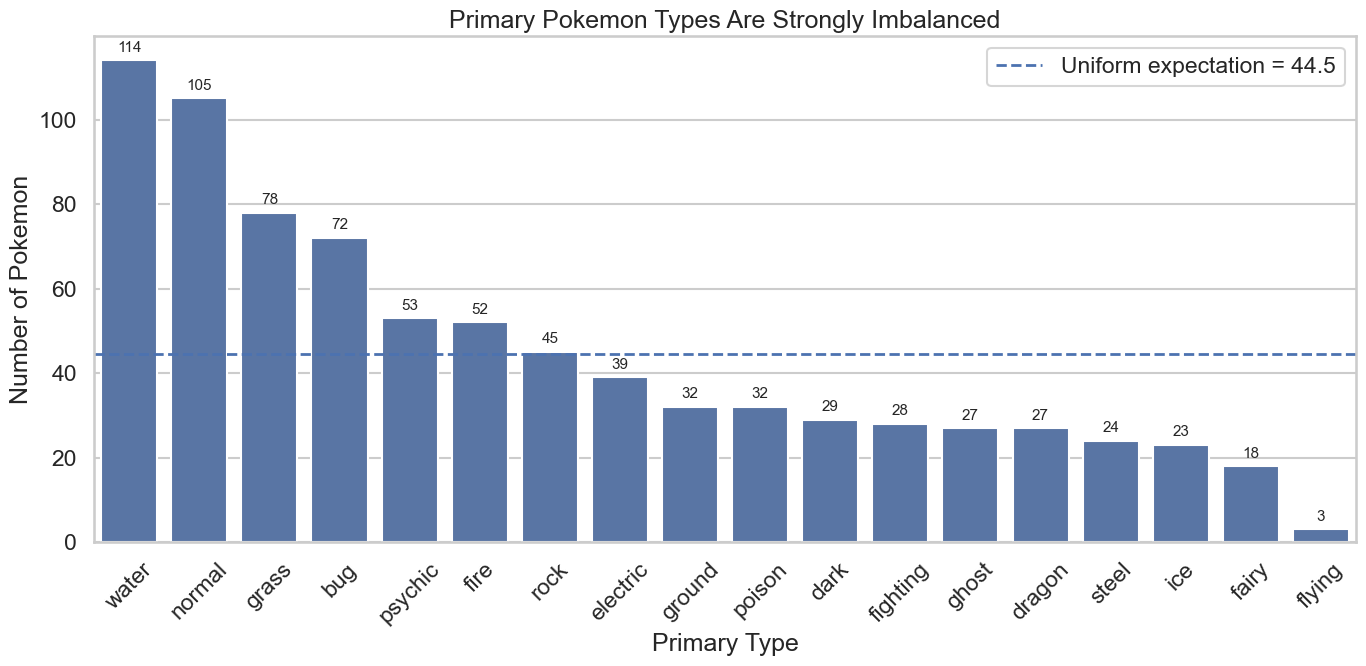

Chi square statistic: 343.2022
P value: 1.275190e-62
Most common primary type: water (114 Pokemon)
Least common primary type: flying (3 Pokemon)


In [5]:
type_counts = pokemon["type1"].value_counts().sort_values(ascending=False)
expected_count = len(pokemon) / type_counts.shape[0]

chi_square_stat, chi_square_p = stats.chisquare(
    f_obs=type_counts.values,
    f_exp=np.repeat(expected_count, type_counts.shape[0])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x=type_counts.index, y=type_counts.values, color="C0", ax=ax)
ax.axhline(expected_count, linestyle="--", linewidth=2, label=f"Uniform expectation = {expected_count:.1f}")

for index, value in enumerate(type_counts.values):
    ax.text(index, value + 2, str(value), ha="center", fontsize=11)

ax.set_title("Primary Pokemon Types Are Strongly Imbalanced")
ax.set_xlabel("Primary Type")
ax.set_ylabel("Number of Pokemon")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Chi square statistic: {chi_square_stat:.4f}")
print(f"P value: {chi_square_p:.6e}")
print(f"Most common primary type: {type_counts.idxmax()} ({type_counts.max()} Pokemon)")
print(f"Least common primary type: {type_counts.idxmin()} ({type_counts.min()} Pokemon)")

**Interpretation.** Water is the most common primary type with **114** Pokemon, while Flying shows up as a primary type only 3 times. That last result makes sense because Flying is often a secondary type instead of a primary type. The imbalance directly reflects how the pokemon are designed in the games.

## Conclusion 2, legendary Pokemon have much higher total stats

To compare overall strength between legendary and non legendary Pokemon, we used a **Welch two sample t test** on `base_total`.

The average `base_total` for legendary Pokemon is **615.3**, compared with **410.5** for non legendary Pokemon. The test result was **t = 19.27** with **p = 4.180e-34**, which is small enough to very confidently reject the idea that the two groups have the same average total stats.

In practical terms, legendary Pokemon are not just a little stronger on average, they are much stronger.

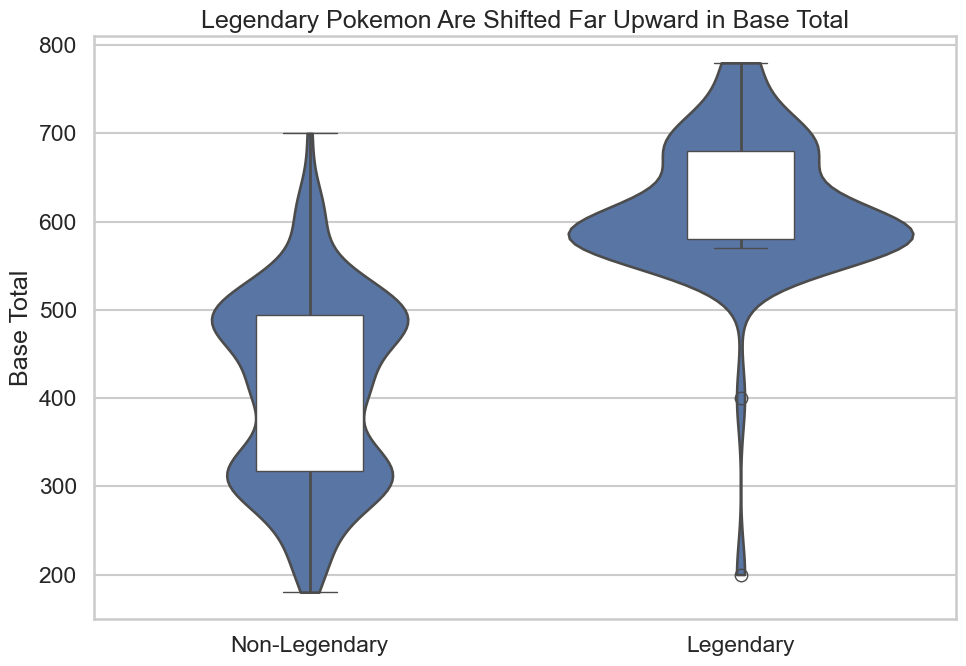

Legendary mean base total: 615.2571
Non legendary mean base total: 410.4815
Welch t statistic: 19.2679
P value: 4.179559e-34


In [6]:
legendary_stats = pokemon.loc[pokemon["is_legendary"] == 1, "base_total"]
nonlegendary_stats = pokemon.loc[pokemon["is_legendary"] == 0, "base_total"]

t_stat, t_p = stats.ttest_ind(
    legendary_stats,
    nonlegendary_stats,
    equal_var=False,
    nan_policy="omit"
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(data=pokemon, x="legendary_label", y="base_total", inner=None, cut=0, color="C0", ax=ax)
sns.boxplot(
    data=pokemon,
    x="legendary_label",
    y="base_total",
    width=0.25,
    showcaps=True,
    boxprops={"facecolor": "white", "zorder": 3},
    whiskerprops={"linewidth": 2},
    ax=ax
)

ax.set_title("Legendary Pokemon Are Shifted Far Upward in Base Total")
ax.set_xlabel("")
ax.set_ylabel("Base Total")
plt.tight_layout()
plt.show()

print(f"Legendary mean base total: {legendary_stats.mean():.4f}")
print(f"Non legendary mean base total: {nonlegendary_stats.mean():.4f}")
print(f"Welch t statistic: {t_stat:.4f}")
print(f"P value: {t_p:.6e}")

**Interpretation.** This result is exactly the kind of pattern we would expect from the game. Legendary Pokemon are meant to be rare and stronger, and the stat distributions show that very clearly. It also tells us that `is_legendary` is a strong explanatory variable for battle power related outcomes.

## Conclusion 3, height and weight are positively related

Our third method is **Pearson correlation** between `height_m` and `weight_kg`.

The correlation is **r = 0.627** with **p = 2.143e-86**. This is a clear positive relationship, so taller Pokemon also tend to weigh more.

The y axis in the plot uses a log scale. That makes the pattern easier to see because a few extremely heavy Pokemon would otherwise squash most of the points near the bottom.

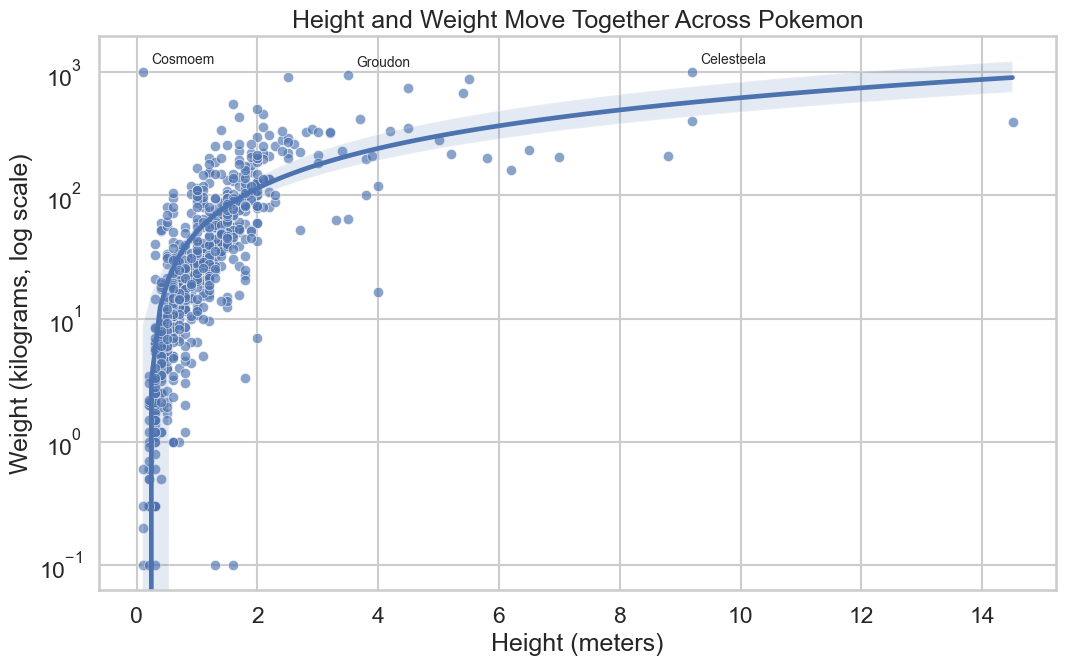

Pearson r: 0.6266
P value: 2.143009e-86
Rows used in this analysis: 781


In [7]:
size_data = pokemon[["name", "height_m", "weight_kg"]].dropna().copy()
r_value, r_p = stats.pearsonr(size_data["height_m"], size_data["weight_kg"])

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=size_data, x="height_m", y="weight_kg", alpha=0.65, s=55, ax=ax)
sns.regplot(data=size_data, x="height_m", y="weight_kg", scatter=False, ax=ax)

for _, row in size_data.nlargest(3, "weight_kg").iterrows():
    ax.annotate(row["name"], (row["height_m"], row["weight_kg"]), xytext=(6, 6), textcoords="offset points", fontsize=10)

ax.set_yscale("log")
ax.set_title("Height and Weight Move Together Across Pokemon")
ax.set_xlabel("Height (meters)")
ax.set_ylabel("Weight (kilograms, log scale)")
plt.tight_layout()
plt.show()

print(f"Pearson r: {r_value:.4f}")
print(f"P value: {r_p:.6e}")
print(f"Rows used in this analysis: {len(size_data)}")

**Interpretation.** Height and weight are related, but not interchangeable. The spread is still wide, especially among large or very unusually built Pokemon. 

## Final Takeaways

1. Pokemon primary types are not evenly represented, so the dataset has a clear type imbalance.
2. Legendary Pokemon stand out as much stronger overall, with much higher average `base_total` values than non legendary Pokemon.
3. Height and weight are clearly related, but the spread in the data suggests each one may provide slightly different information.